inviscid flux jacobian 

F_inviscid(Ui,Uj) = 0.5 (F(Ui) + F(Uj) - |A| * (Uj - Ui))

dF/dUi = 0.5 * (dF/dU (Ui) + |A|)

dF/dUj = 0.5 * (dF/dU (Uj) + |A|)

Functions
- compute_dFdU
- absolute_normal_jacobian (absolute values of jacobian projected to normal direction)
- roe-average states
- inviscid_flux_jacobians

Verifications
- verify compute_dFdU with eigenvalues
- verify absolute_normal_jacobian by aribatry test case, check eigenvalues
- verify compute_dFdU with compute_dFdU_fd
- verify inviscid_flux_jacobians with inviscid_flux_jacobians_fd

Added harten fix to inviscid flux

In [21]:
# compute_dFdU

import numpy as np
import time

def compute_dFdU(U, normal, gamma=1.4):
    """
    Compute the inviscid flux Jacobian matrix for 3D Euler equations.

    Based on equation (A.47) from Chung's Computationa Fluid Dynamics.
    Parameters
    ----------
    U : array-like, shape (5,)
        Conservative variable vector [rho, rho*u, rho*v, rho*w, rho*E]
        where:
        - rho: density
        - u, v, w: velocity components
        - E: specific total energy

    normal : array-like, shape (3,)
        Unit normal vector [n_x, n_y, n_z]

    gamma : float, optional
        Specific heat ratio (default: 1.4 for air)

    Returns
    -------
    dF_dU : ndarray, shape (5, 5)
        Flux Jacobian matrix
    """

    # Extract conservative variables
    rho = U[0]
    rho_u = U[1]
    rho_v = U[2]
    rho_w = U[3]
    rho_E = U[4]

    # Extract normal vector components
    n_x = normal[0]
    n_y = normal[1]
    n_z = normal[2]

    # Compute primitive variables
    u = rho_u / rho
    v = rho_v / rho
    w = rho_w / rho
    E = rho_E / rho

    # Compute auxiliary quantities (from A.48)
    # phi = 0.5 * (gamma - 1) * (u^2 + v^2 + w^2)
    phi = 0.5 * (gamma - 1.0) * (u**2 + v**2 + w**2)

    # V = n_x*u + n_y*v + n_z*w (normal component of velocity)
    V = n_x * u + n_y * v + n_z * w

    # a1 = gamma*E - phi
    a1 = gamma * E - phi

    # a2 = gamma - 1
    a2 = gamma - 1.0

    # a3 = gamma - 2
    a3 = gamma - 2.0

    # Initialize Jacobian matrix
    dF_dU = np.zeros((5, 5))

    # Row 1: d(rho*V)/d(U)
    dF_dU[0, 0] = 0
    dF_dU[0, 1] = n_x
    dF_dU[0, 2] = n_y
    dF_dU[0, 3] = n_z
    dF_dU[0, 4] = 0.0

    # Row 2: d(rho*u*V)/d(U)
    dF_dU[1, 0] = n_x * phi - u * V
    dF_dU[1, 1] = V - a3 * n_x * u
    dF_dU[1, 2] = n_y * u - a2 * n_x *v
    dF_dU[1, 3] = n_z * u - a2 * n_x * w
    dF_dU[1, 4] = a2 * n_x

    # Row 3: d(rho*v*V)/d(U)
    dF_dU[2, 0] = n_y * phi - v * V
    dF_dU[2, 1] = n_x * v - a2 * n_y *u
    dF_dU[2, 2] = V - a3 * n_y * v
    dF_dU[2, 3] = n_z * v - a2 * n_y * w
    dF_dU[2, 4] = a2 * n_y

    # Row 4: d(rho*w*V)/d(U)
    dF_dU[3, 0] = n_z * phi - w * V
    dF_dU[3, 1] = n_x * w - a2 * n_z *u
    dF_dU[3, 2] = n_y * w - a2 * n_z *v
    dF_dU[3, 3] =  V - a3 * n_z * w
    dF_dU[3, 4] = a2 * n_z

    # Row 5: d(rho*H*V)/d(U)
    dF_dU[4, 0] = V * (phi - a1)
    dF_dU[4, 1] = a1 * n_x - a2 * u * V
    dF_dU[4, 2] = a1 * n_y - a2 * v * V
    dF_dU[4, 3] = a1 * n_z - a2 * w * V
    dF_dU[4, 4] = gamma * V

    return dF_dU


# compute_roe_averaged_absolute_jacobian





In [22]:
gamma = 1.4
rho = 1.225        # density (kg/m^3)
u = 300.0          # x-velocity (m/s)
v = 20              # y-velocity (m/s)
w = 25              # w-velocity (m/s)
p = 101325.0       # pressure (Pa)

rhoE = p / (gamma - 1.0) + 0.5 * rho * u**2
rhou = rho * u
rhov = rho * v
rhow = rho * w

# define normal unit vector
n = np.array([1,0,0])

U = np.array([rho, rhou, rhov, rhow, rhoE])
# check A - 1D dFdU
A = compute_dFdU(U, n, gamma)

# check with eigenstructure
# A = R * Lamda * L
# R = right eigenvectors matrix
# L =  left eigenvectors matrix
# Lamda = eigenvalue matrix

# define local speed of sound 
c = np.sqrt(gamma * p / rho)
qn = u * n[0] + v * n[1] + w * n[2]
print("Eigenvalues of A: ",np.linalg.eigvals(A))
print(f"Theorectical eigenvalues of A: {qn-c}, {qn}, {qn+c}, {qn}, {qn}")

Eigenvalues of A:  [639.87203474 300.         -39.87203474 300.         300.        ]
Theorectical eigenvalues of A: -40.29399054347107, 300.0, 640.2939905434711, 300.0, 300.0


Computation of the absolute value of roe-averaged jacobian 
1. absolute value of arbitary jacobian matrix from I do Like CFD equation 3.6.16 to 3.6.26
- Verify by aribitary case of U and n
- Check eigenvalues

2. Plug in roe-averaged states to the function

Point to notes
- this formulation do not need the tangential vectors as in 2D case

3. Added harten entropy correction where

|lamda| = |Lamda| if |Lamda| > eps

|lamda| = (|Lamda|^2+eps^2)/2 if |Lamda| =< eps


In [23]:
"""
Absolute Normal Jacobian |A_n| for the 3D Euler equations.

Reference: equations 3.6.16 – 3.6.26.

Conservative variable vector:
    U = [rho, rho*u, rho*v, rho*w, rho*E]   (shape 5)

The result is assembled from three contributions (eqs. 3.6.24 – 3.6.26):

    |A_n| = |qn - c| * r1*l1^T          (eq. 3.6.25)
          + |qn|     * (r2*l2^T + r4*l4^T + r5*l5^T)   (eq. 3.6.24)
          + |qn + c| * r3*l3^T          (eq. 3.6.26)
"""
def _harten(lam, eps):
    lam = np.asarray(lam, dtype=float)
    if eps == 0.0:
        return np.abs(lam)
    return np.where(np.abs(lam) >= eps,
                    np.abs(lam),
                    (lam**2 + eps**2) / (2.0 * eps))


def absolute_normal_jacobian(U, n, gamma=1.4, harten_eps=0.0):
    """
    Absolute-value normal Jacobian |A_n|.
    harten_eps : Harten entropy fix threshold (fraction of (|qn|+c)).
                 0.0 = disabled (default, backward-compatible)
                 0.1–0.3 typical for transonic/shock flows
    """
    U  = np.asarray(U, dtype=float)
    n  = np.asarray(n, dtype=float);  n = n / np.linalg.norm(n)
    rho = U[0];  vel = U[1:4] / rho;  E = U[4] / rho
    q2  = np.dot(vel, vel)
    p   = (gamma - 1.0) * rho * (E - 0.5*q2)
    c   = np.sqrt(gamma * p / rho)
    H   = E + p / rho
    qn  = np.dot(vel, n)
    M2  = q2 / c**2;  Mn = qn / c;  g1 = gamma - 1.0

    # ── Harten-smoothed eigenvalue magnitudes ────────────────────────────────
    delta = harten_eps * (abs(qn) + c)          # local threshold
    lam1  = _harten(qn - c, delta)              # acoustic  (left)
    lam2  = _harten(qn,     delta)              # entropy / shear
    lam3  = _harten(qn + c, delta)              # acoustic  (right)

    # |qn| contribution
    mid = np.zeros((5, 5))
    mid[0, 0]     =  1.0 - 0.5*g1*M2
    mid[0, 1:4]   =  (g1/c**2)*vel;  mid[0, 4] = -(g1/c**2)
    mid[1:4, 0]   = -0.5*g1*M2*vel + qn*n
    mid[1:4, 1:4] =  (g1/c**2)*np.outer(vel, vel) + np.eye(3) - np.outer(n, n)
    mid[1:4, 4]   = -(g1/c**2)*vel
    mid[4, 0]     =  qn**2 - 0.5*q2*(1.0 + 0.5*g1*M2)
    mid[4, 1:4]   =  (1.0 + 0.5*g1*M2)*vel - qn*n;  mid[4, 4] = -0.5*g1*M2

    # |qn - c| contribution
    l1 = np.empty(5)
    l1[0] = 0.25*g1*M2 + 0.5*Mn
    l1[1:4] = -(g1/(2*c**2))*vel - n/(2*c);  l1[4] = g1/(2*c**2)
    r1 = np.empty(5)
    r1[0] = 1.0;  r1[1:4] = vel - c*n;  r1[4] = H - qn*c
    A1 = np.outer(r1, l1)

    # |qn + c| contribution
    l3 = np.empty(5)
    l3[0] = 0.25*g1*M2 - 0.5*Mn
    l3[1:4] = -(g1/(2*c**2))*vel + n/(2*c);  l3[4] = g1/(2*c**2)
    r3 = np.empty(5)
    r3[0] = 1.0;  r3[1:4] = vel + c*n;  r3[4] = H + qn*c
    A3 = np.outer(r3, l3)

    return lam1*A1 + lam2*mid + lam3*A3

In [24]:
# Verification of absolute_normal_jacobian(U, n, gamma=1.4)
# Check eigenvalues of abs_An

# define testing U
rho = 1.2
vel = np.array([300.0, 50.0, -20.0])
p   = 101325.0
E   = p / ((gamma - 1) * rho) + 0.5 * np.dot(vel, vel)

U   = np.array([rho, rho*vel[0], rho*vel[1], rho*vel[2], rho*E])

# define normal unit vector
n = np.array([1.0, 0.5, 0.2])
n_unit = n / np.linalg.norm(n)          # normalize first

# compute absolute normal jacobian (absolute of jacobian projeceted to normal vector)
abs_An = absolute_normal_jacobian(U, n_unit, gamma=1.4)

# compute eigenvalues and eigenvectors
eigenvalues = np.linalg.eigvals(abs_An)

# theorectical eigenvalues of the absolute jacobian 
qn = vel @ n_unit
c = np.sqrt(gamma * p / rho)

theoretical_eigenvalues = np.array([np.abs(qn-c), qn, qn+c, qn, qn])

print("Eigenvalues of An: ",np.sort(eigenvalues))
print("Theorectical eigenvalues of An:", np.sort(theoretical_eigenvalues))


Eigenvalues of An:  [ 61.1957064  282.62474093 282.62474093 282.62474093 626.44518826]
Theorectical eigenvalues of An: [ 61.1957064  282.62474093 282.62474093 282.62474093 626.44518826]


In [25]:
# function to output roe-averages

def roe_average(UL, UR, gamma=1.4):
    """
    Compute the Roe-averaged conservative variable vector for the 3D Euler equations.
 
    Parameters
    ----------
    UL, UR : array-like, shape (5,)
        Left/right conservative vectors [rho, rho*u, rho*v, rho*w, rho*E].
    gamma : float
        Ratio of specific heats (default 1.4).
 
    Returns
    -------
    U_roe : ndarray, shape (5,)
        Roe-averaged conservative variable vector.
    """
    UL = np.asarray(UL, dtype=float)
    UR = np.asarray(UR, dtype=float)
 
    rhoL, rhoR = UL[0], UR[0]
    velL = UL[1:4] / rhoL
    velR = UR[1:4] / rhoR
    EL   = UL[4] / rhoL
    ER   = UR[4] / rhoR
 
    pL = (gamma - 1.0) * rhoL * (EL - 0.5 * np.dot(velL, velL))
    pR = (gamma - 1.0) * rhoR * (ER - 0.5 * np.dot(velR, velR))
    HL = EL + pL / rhoL    # total enthalpy per unit mass
    HR = ER + pR / rhoR
 
    wL = np.sqrt(rhoL)     # Roe weight for left state
    wR = np.sqrt(rhoR)     # Roe weight for right state
    ws = wL + wR
 
    rho_roe = wL * wR                          # = sqrt(rhoL * rhoR)
    vel_roe = (wL * velL + wR * velR) / ws
    H_roe   = (wL * HL   + wR * HR)   / ws
 
    # Recover E from H:  H = gamma*E - (gamma-1)/2 * |v|^2
    q2_roe = np.dot(vel_roe, vel_roe)
    E_roe  = (H_roe + (gamma - 1.0) * 0.5 * q2_roe) / gamma
 
    U_roe = np.empty(5)
    U_roe[0]   = rho_roe
    U_roe[1:4] = rho_roe * vel_roe
    U_roe[4]   = rho_roe * E_roe
    
    return U_roe

In [26]:
# inviscid_flux_jacobians
def inviscid_flux_jacobians(U_i, U_j, n, gamma=1.4, harten_eps=0.0):
    U_roe     = roe_average(U_i, U_j, gamma)
    abs_A_roe = absolute_normal_jacobian(U_roe, n, gamma=gamma, harten_eps=harten_eps)
    J_L = 0.5 * (compute_dFdU(U_i, n, gamma) + abs_A_roe)
    J_R = 0.5 * (compute_dFdU(U_j, n, gamma) - abs_A_roe)
    return J_L, J_R

In [27]:
def euler_flux(U, n, gamma=1.4):
    """
    Computes the Euler flux projected onto normal n. (Euler normal flux)
    U  = [rho, rhou, rhov, rhow, rhoE]
    n  = [nx, ny, nz]  (need not be unit)
    F  = [rho*un, rhou*un + P*nx, rhov*un + P*ny, rhow*un + P*nz, (rhoE+P)*un]
    un = u*nx + v*ny + w*nz
    """
    rho  = U[0]
    rhou = U[1]; rhov = U[2]; rhow = U[3]; rhoE = U[4]

    u = rhou / rho
    v = rhov / rho
    w = rhow / rho

    nx, ny, nz = n[0], n[1], n[2]
    un = u * nx + v * ny + w * nz                         # fix 1

    P = (gamma - 1.0) * (rhoE - 0.5 * rho * (u**2 + v**2 + w**2))  # fix 2

    F = np.zeros(5)                                       # fix 3
    F[0] = rho  * un
    F[1] = rhou * un + P * nx
    F[2] = rhov * un + P * ny
    F[3] = rhow * un + P * nz
    F[4] = (rhoE + P) * un

    return F


def compute_dFdU_fd(U, n, eps, gamma=1.4):
    """
    Computes the 3D Euler Flux Jacobian dF/dU by forward finite differences.

    Parameters
    ----------
    U     : ndarray (5,)  [rho, rhou, rhov, rhow, rhoE]
    n     : ndarray (3,)  face normal vector
    eps   : float         perturbation step size
    gamma : float         ratio of specific heats

    Returns
    -------
    dFdU : ndarray (5, 5)
    """
    F_base = euler_flux(U, n, gamma)
    dFdU   = np.zeros((5, 5))
    I      = np.eye(5)

    for j in range(5):
        Up = U + eps * I[:, j]
        dFdU[:, j] = (euler_flux(Up, n, gamma) - F_base) / eps

    return dFdU

# inviscid_flux_jacobians by finite difference

def inviscid_flux_jacobians_fd(U_i, U_j, n, eps, gamma=1.4):
    """
    Compute the normal inviscid flux Jacobian blocks at a cell face between
    cell i (left/owner) and cell j (right/neighbor).

    Parameters
    ----------
    U_i, U_j : array_like, shape (5,)
        Conservative variables [rho, rho*u, rho*v, rho*w, rho*E] of the
        two cells sharing the face.
    n : array_like, shape (3,)
        Unit normal vector [nx, ny, nz] of the face, pointing from i to j.
    gamma: float
        Ratio of specific heats
    Returns
    -------
    d(F)/d(U_i)  -- Inviscid Jacobian wrt the left-cell conservative state.
    d(F)/d(U_j)  -- Inviscid Jacobian wrt the right-cell conservative state.
    """
    U_roe     = roe_average(U_i, U_j, gamma)
    abs_A_roe = absolute_normal_jacobian(U_roe, n, gamma=gamma)
    dFdUi = 0.5 * (compute_dFdU_fd(U_i, n, eps, gamma) + abs_A_roe)
    dFdUj = 0.5 * (compute_dFdU_fd(U_j, n, eps, gamma) - abs_A_roe)
    return dFdUi, dFdUj

Checking the Harten Entorpy Fix with 4 tests

Essence of Harten Entropy Fix
- make sure |qn-c| is not that close to zero when it is by smoothening it

1. Visual smoothness near sonic point
- Sweep Mach number through 1.0 and plot |qn - c| with and without the fix. You should see the kink at Mn=1 replaced by a smooth parabola

2. Positive semi-definiteness of |A_roe| near sonic
- Without fix, |A_roe| can have near-zero or slightly negative eigenvalues right at sonic. With fix, all eigenvalues must be ≥ δ > 0.

3. Rankine-Hugoniot shock: F(U_i) = F(U_j), U_i ≠ U_j
- Construct a physically valid normal shock using the RH jump conditions. The Roe flux should recover the exact flux on both sides. The Harten fix should not break flux consistency.

4. Entropy condition: transonic expansion (the problematic case)
- Without the fix, Roe can produce an expansion shock at a sonic point — a non-physical solution where entropy decreases. The Harten fix prevents this by adding dissipation. Check that the dissipation term |A_roe| @ (U_R - U_L) does not vanish when it should not.

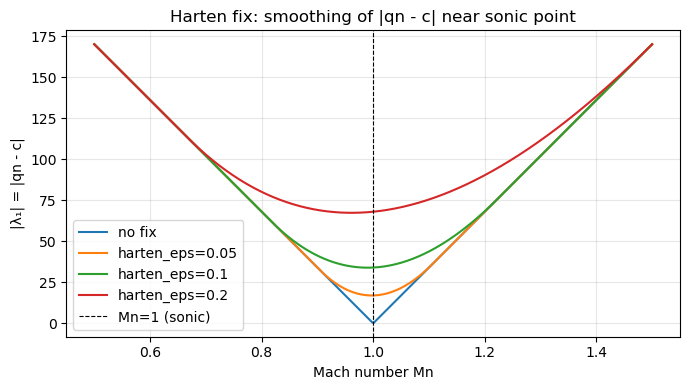

In [28]:
# test 1
import matplotlib.pyplot as plt

def _eigenvalue_sweep(harten_eps_vals, gamma=1.4):
    rho = 1.225; p = 101325.0
    c   = np.sqrt(gamma * p / rho)
    Mn_range = np.linspace(0.5, 1.5, 500)
    n = np.array([1., 0., 0.])

    fig, ax = plt.subplots(figsize=(7, 4))
    for eps_frac in harten_eps_vals:
        lam1_vals = []
        for Mn in Mn_range:
            u = Mn * c
            E = p / ((gamma-1)*rho) + 0.5*u**2
            U = np.array([rho, rho*u, 0., 0., rho*E])
            delta = eps_frac * (abs(u) + c)
            lam1  = _harten(u - c, delta)
            lam1_vals.append(lam1)
        label = f"harten_eps={eps_frac}" if eps_frac > 0 else "no fix"
        ax.plot(Mn_range, lam1_vals, label=label)

    ax.axvline(1.0, color='k', linestyle='--', lw=0.8, label='Mn=1 (sonic)')
    ax.set_xlabel('Mach number Mn');  ax.set_ylabel('|λ₁| = |qn - c|')
    ax.set_title('Harten fix: smoothing of |qn - c| near sonic point')
    ax.legend();  ax.grid(alpha=0.3)
    plt.tight_layout();  plt.show()

_eigenvalue_sweep([0.0, 0.05, 0.1, 0.2])

2. Positive semi-definiteness of |A_roe| near sonic
- Without fix, |A_roe| can have near-zero or slightly negative eigenvalues right at sonic. With fix, all eigenvalues must be ≥ δ > 0.
- try with case when the flow is near sonic, M = 1, flow in x-direction only

In [29]:
print("=" * 60)
print("Test B: min eigenvalue of |A_roe| near sonic (should be >= 0)")
print("=" * 60)

rho = 1.225;  p = 101325.0;  gamma = 1.4
c   = np.sqrt(gamma * p / rho)
n   = np.array([1., 0., 0.]) # in x-direction only

# theoretical eigenvalues for reference
qn_theoretical = {}

for Mn in [0.99, 1.00, 1.01]:
    u = Mn * c
    E = p / ((gamma-1)*rho) + 0.5*u**2
    U = np.array([rho, rho*u, 0., 0., rho*E])
    qn = u * n[0]    # only x-component of vel is nonzero
    theo = np.sort([abs(qn-c), abs(qn), abs(qn), abs(qn), abs(qn+c)])
    print(f"\n  Mn={Mn:.2f}  qn={qn:.1f}  c={c:.1f}  theoretical |λ|: {theo}")
    for eps_frac in [0.0, 0.1]:
        absA   = absolute_normal_jacobian(U, n, gamma=gamma, harten_eps=eps_frac)
        eigv   = np.linalg.eigvals(absA).real      # <-- fixed
        min_ev = eigv.min()
        tag    = "eps=0.0 (no fix)" if eps_frac == 0 else f"eps={eps_frac}"
        status = "OK" if min_ev >= -1e-6 else "NEGATIVE <- problem"
        print(f"  {tag:20s}  eigs={np.sort(eigv)}  min={min_ev:+.4e}  {status}")

Test B: min eigenvalue of |A_roe| near sonic (should be >= 0)

  Mn=0.99  qn=336.9  c=340.3  theoretical |λ|: [  3.40293991 336.89105064 336.89105064 336.89105064 677.18504118]
  eps=0.0 (no fix)      eigs=[  3.40293991 336.89105064 336.89105064 336.89105064 677.18504118]  min=+3.4029e+00  OK
  eps=0.1               eigs=[ 33.94475306 336.89105064 336.89105064 336.89105064 677.18504118]  min=+3.3945e+01  OK

  Mn=1.00  qn=340.3  c=340.3  theoretical |λ|: [  0.         340.29399054 340.29399054 340.29399054 680.58798109]
  eps=0.0 (no fix)      eigs=[-2.21355891e-13  3.40293991e+02  3.40293991e+02  3.40293991e+02
  6.80587981e+02]  min=-2.2136e-13  OK
  eps=0.1               eigs=[ 34.02939905 340.29399054 340.29399054 340.29399054 680.58798109]  min=+3.4029e+01  OK

  Mn=1.01  qn=343.7  c=340.3  theoretical |λ|: [  3.40293991 343.69693045 343.69693045 343.69693045 683.99092099]
  eps=0.0 (no fix)      eigs=[  3.40293991 343.69693045 343.69693045 343.69693045 683.99092099]  min=+3.4029e

In [34]:
def rankine_hugoniot_downstream(rho1, u1, p1, gamma=1.4):
    c1 = np.sqrt(gamma * p1 / rho1)
    M1 = u1 / c1
    assert M1 > 1.0, "Upstream must be supersonic"
    g    = gamma
    rho2 = rho1 * (g+1)*M1**2 / ((g-1)*M1**2 + 2)
    p2   = p1   * (2*g*M1**2 - (g-1)) / (g+1)
    u2   = rho1 * u1 / rho2
    return rho2, u2, p2

rho1, u1, p1 = 1.225, 500.0, 101325.0
rho2, u2, p2 = rankine_hugoniot_downstream(rho1, u1, p1, gamma)

E1 = p1 / ((gamma-1)*rho1) + 0.5*u1**2
E2 = p2 / ((gamma-1)*rho2) + 0.5*u2**2
U1 = np.array([rho1, rho1*u1, 0., 0., rho1*E1])
U2 = np.array([rho2, rho2*u2, 0., 0., rho2*E2])
n  = np.array([1., 0., 0.])

F1 = euler_flux(U1, n, gamma)
F2 = euler_flux(U2, n, gamma)

print("=" * 60)
print("Test C: Rankine-Hugoniot shock consistency")
print("=" * 60)
print(f"  M1 = {u1/np.sqrt(gamma*p1/rho1):.3f}  ->  M2 = {u2/np.sqrt(gamma*p2/rho2):.3f}")
print(f"  |F(U1) - F(U2)| max = {np.max(np.abs(F1 - F2)):.2e}  (should be ~1e-10)")

for eps_frac in [0.0, 0.05, 0.1, 0.2]: 
    U_roe = roe_average(U1, U2, gamma)
    absA  = absolute_normal_jacobian(U_roe, n, gamma, harten_eps=eps_frac)
    F_roe = 0.5*(F1 + F2) - 0.5 * absA @ (U2 - U1)
    err   = np.max(np.abs(F_roe - F1))
    print(f"  harten_eps={eps_frac:.2f}  |F_roe - F_exact| = {err:.4e}")

Test C: Rankine-Hugoniot shock consistency
  M1 = 1.469  ->  M2 = 0.712
  |F(U1) - F(U2)| max = 8.94e-08  (should be ~1e-10)
  harten_eps=0.00  |F_roe - F_exact| = 5.8208e-11
  harten_eps=0.05  |F_roe - F_exact| = 2.5461e+06
  harten_eps=0.10  |F_roe - F_exact| = 5.0922e+06
  harten_eps=0.20  |F_roe - F_exact| = 1.0184e+07


In [35]:
print("=" * 60)
print("Test D: Entropy dissipation at sonic expansion")
print("=" * 60)

rho = 1.225; p = 101325.0; gamma = 1.4
c   = np.sqrt(gamma * p / rho)
n   = np.array([1., 0., 0.])

# Left state: slightly supersonic (qn > c)
# Right state: slightly subsonic (qn < c)
# This mimics a transonic expansion fan passing through sonic
u_L = 1.05 * c;  E_L = p / ((gamma-1)*rho) + 0.5*u_L**2
u_R = 0.95 * c;  E_R = p / ((gamma-1)*rho) + 0.5*u_R**2
U_L = np.array([rho, rho*u_L, 0., 0., rho*E_L])
U_R = np.array([rho, rho*u_R, 0., 0., rho*E_R])

print(f"  Left  state: Mn = {u_L/c:.2f}  (supersonic)")
print(f"  Right state: Mn = {u_R/c:.2f}  (subsonic)")
print(f"  c = {c:.2f} m/s\n")

for eps_frac in [0.0, 0.05, 0.1, 0.2]:
    U_roe  = roe_average(U_L, U_R, gamma)
    absA   = absolute_normal_jacobian(U_roe, n, gamma, harten_eps=eps_frac)
    diss   = absA @ (U_R - U_L)
    min_ev = np.linalg.eigvals(absA).real.min()
    tag    = "no fix" if eps_frac == 0 else f"eps={eps_frac}"
    print(f"  {tag:12s}  diss[rho]={diss[0]:+.4e}  "
          f"diss[rhou]={diss[1]:+.4e}  min_eig={min_ev:.4e}")

print()
print("  no fix : diss -> 0 at sonic => expansion shock possible")
print("  with fix: diss > 0 at sonic => physically correct expansion fan")

Test D: Entropy dissipation at sonic expansion
  Left  state: Mn = 1.05  (supersonic)
  Right state: Mn = 0.95  (subsonic)
  c = 340.29 m/s

  no fix        diss[rho]=-4.1676e+01  diss[rhou]=-2.8371e+04  min_eig=8.5063e-02
  eps=0.05      diss[rho]=-4.0639e+01  diss[rhou]=-2.8371e+04  min_eig=1.7017e+01
  eps=0.1       diss[rho]=-3.9597e+01  diss[rhou]=-2.8371e+04  min_eig=3.4034e+01
  eps=0.2       diss[rho]=-3.7513e+01  diss[rhou]=-2.8371e+04  min_eig=6.8067e+01

  no fix : diss -> 0 at sonic => expansion shock possible
  with fix: diss > 0 at sonic => physically correct expansion fan
